## Setup

In [1]:
# macOS note: xgboost and sentence-transformers (PyTorch) each bring their own
# OpenMP runtime. If PyTorch loads first, using xgboost afterwards crashes the
# kernel. Importing xgboost FIRST (before sentence-transformers) avoids the clash.
# Keep this as the very first cell you run.
from xgboost import XGBClassifier

## Load Data

In [2]:
import pandas as pd

# Load the synthetic patient dataset
df = pd.read_excel('../data/raw/nurseassist_patient_dataset_210_rows.xlsx', sheet_name='Patient Dataset')

# Number of patient rows per illness
df['Primary_Illness'].value_counts()

Primary_Illness
Influenza                          27
Gastrointestinal infection         21
Common cold                        19
Pneumonia                          19
Post-operative wound infection     18
COPD exacerbation                  17
Urinary tract infection            16
Hypertension                       15
Sepsis risk                        15
Strep throat                       14
Skin/wound infection               14
Asthma exacerbation                14
Sepsis risk from skin infection     1
Name: count, dtype: int64

## Features

In [ ]:
# Vitals (numeric, model-ready) and the illness label
vital_cols = [
    'Temperature_C',
    'Heart_Rate_bpm',
    'Systolic_BP_mmHg',
    'Diastolic_BP_mmHg',
    'SpO2_percent',
    'Respiratory_Rate_bpm',
    'Pain_0_10',
]
label_col = 'Primary_Illness'

# Read the processed data file (vitals + symptom embeddings + illness label).
# This file is built by src/embedding_features.py. Run that file only when you
# want to rebuild it:  python src/embedding_features.py
# (synthetic / educational only)
classification_df = pd.read_csv('../data/processed/illness_classification_data.csv')

# Embedding feature columns (emb_0, emb_1, ...) for use further down
embedding_cols = [c for c in classification_df.columns if c.startswith('emb_')]

classification_df.head()

## Filter & Split

In [4]:
# Some illnesses have too few patients to split and validate.
# Stratified splitting needs >= 2 per class, and StratifiedKFold(5) needs >= 5,
# so we keep only illnesses with at least 5 patients. (synthetic / educational data)
MIN_PER_CLASS = 5

class_counts = classification_df[label_col].value_counts()
keep_classes = class_counts[class_counts >= MIN_PER_CLASS].index

# Keep only illnesses with enough patients
classification_df = classification_df[classification_df[label_col].isin(keep_classes)].reset_index(drop=True)

# Remaining patients per illness after filtering
classification_df[label_col].value_counts()

Primary_Illness
Influenza                         27
Gastrointestinal infection        21
Common cold                       19
Pneumonia                         19
Post-operative wound infection    18
COPD exacerbation                 17
Urinary tract infection           16
Hypertension                      15
Sepsis risk                       15
Strep throat                      14
Skin/wound infection              14
Asthma exacerbation               14
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Features (X) = vitals + symptom embeddings; label (y) = illness
feature_cols = vital_cols + embedding_cols
X = classification_df[feature_cols]
y = classification_df[label_col]

# random_state makes the split reproducible (same rows every run)
RANDOM_STATE = 42

# 80-20 split: hold out 20% as the test set we never touch during training.
# stratify=y keeps each illness represented proportionally in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Validation = k-fold cross-validation on the TRAIN set (not a fixed val split).
# StratifiedKFold keeps class balance inside each fold. 5 folds is a common default.
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Confirm the split sizes
pd.DataFrame({
    'rows': [len(X_train), len(X_test)],
}, index=['train', 'test'])

In [6]:
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels, so turn illness names into integer codes (0, 1, 2, ...).
# This is NOT embedding — the classes carry no similarity, just distinct IDs.
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Map of which illness became which number
dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

{'Asthma exacerbation': 0,
 'COPD exacerbation': 1,
 'Common cold': 2,
 'Gastrointestinal infection': 3,
 'Hypertension': 4,
 'Influenza': 5,
 'Pneumonia': 6,
 'Post-operative wound infection': 7,
 'Sepsis risk': 8,
 'Skin/wound infection': 9,
 'Strep throat': 10,
 'Urinary tract infection': 11}

## Model

In [7]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import numpy as np

# Baseline XGBoost model. learning_rate=0.1 is a standard starting value.
# (We'll compare other learning rates in the next experiment.)
xgb_model = XGBClassifier(
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
)

# Validate with 5-fold cross-validation on the training set.
# This gives 5 accuracy scores; the mean is our validation score to compare later.
cv_scores = cross_val_score(xgb_model, X_train, y_train_encoded, cv=kfold, scoring='accuracy')

print(f"Fold accuracies: {np.round(cv_scores, 3)}")
print(f"Mean validation accuracy (learning_rate=0.1): {cv_scores.mean():.3f}")

Fold accuracies: [0.824 0.853 0.909 0.788 0.879]
Mean validation accuracy (learning_rate=0.1): 0.850


## Hyperparameter Tuning

In [8]:
def evaluate_params(lr, n_estimators=100, max_depth=6):
    """Run 5-fold cross-validation for one XGBoost hyperparameter combo.

    n_estimators and max_depth default to baseline values so we can sweep
    just one setting at a time. Trains on the training set only (test set
    stays untouched). Returns the settings plus the mean validation accuracy
    and its standard deviation across the 5 folds.
    """
    model = XGBClassifier(
        learning_rate=lr,
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=RANDOM_STATE,
        eval_metric='mlogloss',
    )
    scores = cross_val_score(model, X_train, y_train_encoded, cv=kfold, scoring='accuracy')
    return {
        'learning_rate': lr,
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'mean_val_accuracy': scores.mean(),
        'std': scores.std(),
    }

In [9]:
# --- n_estimators experiment (commented out: proved no effect, see note below) ---
# Grid search: try every combination of learning rate and n_estimators
# using the same 5-fold cross-validation. (Test set stays untouched.)
# results = []
# for lr in [0.3, 0.2, 0.1, 0.05, 0.01]:
#     for n in [100, 300, 500, 1000]:
#         results.append(evaluate_params(lr, n))
#
# # Sorted so the best combination sits at the top
# results_df = pd.DataFrame(results).sort_values('mean_val_accuracy', ascending=False).reset_index(drop=True)
# results_df

In [10]:
# --- n_estimators plot (commented out: belongs to the n_estimators experiment above) ---
# import matplotlib.pyplot as plt
#
# # One line per n_estimators value, plotted across learning rates.
# fig, ax = plt.subplots(figsize=(8, 5))
#
# for n in sorted(results_df['n_estimators'].unique()):
#     subset = results_df[results_df['n_estimators'] == n].sort_values('learning_rate')
#     ax.plot(
#         subset['learning_rate'],
#         subset['mean_val_accuracy'],
#         marker='o',
#         label=f'n_estimators={n}',
#     )
#
# ax.set_xlabel('Learning rate')
# ax.set_ylabel('Mean validation accuracy (5-fold CV)')
# ax.set_title('XGBoost: learning rate vs validation accuracy by n_estimators')
# ax.legend()
# ax.grid(True, alpha=0.3)
# fig.tight_layout()

### n_estimators experiment — conclusion

The grid search above showed that changing `n_estimators` (100 → 1000) had **no effect** on validation accuracy: for each learning rate, every `n_estimators` value produced the same score. The model converges within 100 trees on this small dataset, so extra trees add nothing.

**Decision:** fix `n_estimators = 100` and do not sweep it further. The cells are kept commented out as a record. Next, we test `max_depth`.

In [11]:
# max_depth experiment: sweep learning rate x max_depth, with n_estimators fixed at 100.
# Shallow trees often generalize better on small datasets, so we test small depths.
depth_results = []
for lr in [0.3, 0.2, 0.1, 0.05, 0.01]:
    for depth in [2, 3, 4, 6]:
        depth_results.append(evaluate_params(lr, max_depth=depth))

# Sorted so the best combination sits at the top
depth_results_df = pd.DataFrame(depth_results).sort_values('mean_val_accuracy', ascending=False).reset_index(drop=True)
depth_results_df

,learning_rate,n_estimators,max_depth,mean_val_accuracy,std
0,0.20,100,2,0.874153,0.048475
1,0.20,100,3,0.874153,0.048475
2,0.20,100,4,0.874153,0.048475
3,0.20,100,6,0.874153,0.048475
4,0.30,100,2,0.862210,0.041205
5,0.30,100,4,0.862210,0.041205
6,0.30,100,6,0.862210,0.041205
7,0.30,100,3,0.862210,0.041205
8,0.05,100,2,0.856328,0.044106
9,0.05,100,6,0.856328,0.044106


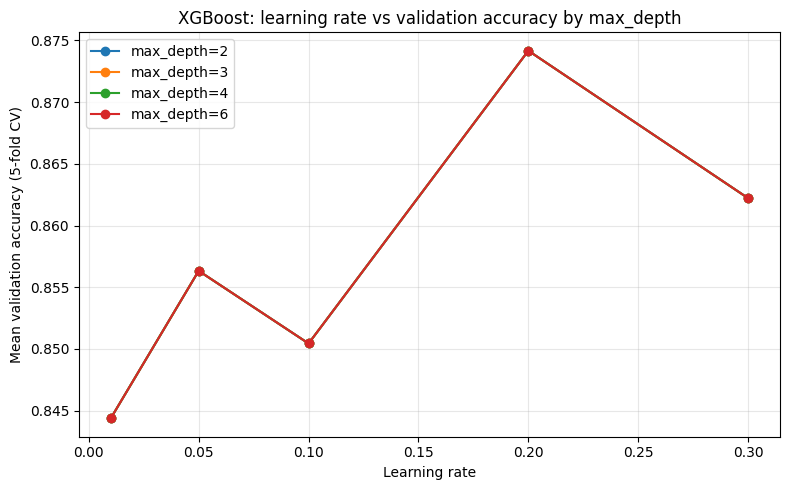

In [ ]:
import matplotlib.pyplot as plt

# One line per max_depth value, plotted across learning rates,
# so we can see how tree depth and learning rate interact.
fig, ax = plt.subplots(figsize=(8, 5))

for depth in sorted(depth_results_df['max_depth'].unique()):
    subset = depth_results_df[depth_results_df['max_depth'] == depth].sort_values('learning_rate')
    ax.plot(
        subset['learning_rate'],
        subset['mean_val_accuracy'],
        marker='o',
        label=f'max_depth={depth}',
    

ax.set_xlabel('Learning rate')
ax.set_ylabel('Mean validation accuracy (5-fold CV)')
ax.set_title('XGBoost: learning rate vs validation accuracy by max_depth')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()

In [13]:
# Best combination from the max_depth experiment (top row of the sorted table)
best = depth_results_df.iloc[0]
print(
    f"Best combination: learning_rate={best['learning_rate']}, "
    f"max_depth={int(best['max_depth'])}, n_estimators={int(best['n_estimators'])}"
)
print(f"Mean validation accuracy: {best['mean_val_accuracy']:.3f} (std {best['std']:.3f})")

Best combination: learning_rate=0.2, max_depth=2, n_estimators=100
Mean validation accuracy: 0.874 (std 0.048)


## Best Parameter Values

In [ ]:
import json
from pathlib import Path

# Pull the winning hyperparameters (chosen by cross-validation accuracy) and
# save them so the model file can read them without re-running this notebook.
best_params = {
    'model_type': 'xgboost',
    'params': {
        'learning_rate': float(best['learning_rate']),
        'max_depth': int(best['max_depth']),
        'n_estimators': int(best['n_estimators']),
    },
}

# Write to the model_params/ folder (one JSON per model).
params_path = Path('../model_params/illness_classifier_hyperparameters.json')
params_path.parent.mkdir(parents=True, exist_ok=True)
with open(params_path, 'w') as f:
    json.dump(best_params, f, indent=2)

best_params